In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import sys
sys.path.append("/content/drive/MyDrive")
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision.io import read_image
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from PIL import Image

from image_processing import select_concept_images, sample_images, get_resnet_dataloader
from utils import flatten, get_activations, get_grads

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [ ]:
batch_size = 16
num_concept_images = 100
num_target_images = 20
target_class = "zebra"
positive_concept = "striped" #"bubbly"
negative_concept = "dotted"

In [ ]:
%cd /content/drive/MyDrive/data

!mkdir -p broden
%cd broden

!wget https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz
!tar -xzf dtd-r1.0.1.tar.gz

!mv dtd/images/* dtd/
!rmdir dtd/images

In [ ]:
%cd /content/drive/MyDrive/data/imagenet
!mkdir -p zebra
!mv volcano_zebra.jpg zebra/
!cd /content/drive/MyDrive/data/imagenet/zebra

!wget https://image-net.org/data/winter21_whole/n02391049.tar
!tar -xf n02391049.tar
!rm n02391049.tar


In [ ]:
!mv *.JPEG zebra/
!mv *.jpg zebra/ 2>/dev/null

In [ ]:
# @title
!huggingface-cli login

In [ ]:
# @title
from datasets import load_dataset

imagenet = load_dataset(
    "ILSVRC/imagenet-1k",
    split="train",
    streaming=True
)

# Zebra = label 340
zebra_images = []
for ex in imagenet:
    if ex["label"] == 340:
        zebra_images.append(ex["image"])
    if len(zebra_images) == 20:
        break

print(len(zebra_images))


In [ ]:
# @title
dtd = load_dataset(
    "cansa/Describable-Textures-Dataset-DTD",
    split="train",
    streaming=True
)

positive_concept_name = "striped"
negative_concept_name = "dotted"

# Get the ClassLabel features to map names to IDs
features = dtd.features
label_names = features["label"].names

positive_concept_id = label_names.index(positive_concept_name)
negative_concept_id = label_names.index(negative_concept_name)

p_concept_images = []
n_concept_images = []

for ex in dtd:
    if ex["label"] == positive_concept_id:
        p_concept_images.append(ex["image"])
    elif ex["label"] == negative_concept_id:
        n_concept_images.append(ex["image"])

    if len(p_concept_images) >= 50 and len(n_concept_images) >= 50:
        break

print("Striped:", len(p_concept_images))
print("Dotted:", len(n_concept_images))

In [ ]:
# @title
from datasets import load_dataset

imagenet = load_dataset(
    "ILSVRC/imagenet-1k",
    split="train",
    streaming=True
)

# Zebra = label 340
zebra_images = []
for ex in imagenet:
    if ex["label"] == 340:
        zebra_images.append(ex["image"])
    if len(zebra_images) == 20:
        break

print(len(zebra_images))

In [ ]:
# @title
import os
drive_base_path = "/content/drive/MyDrive/data/dtd/"
os.makedirs(drive_base_path, exist_ok=True)
for i, img in enumerate(n_concept_images):
    img.save(f"{drive_base_path}/striped_{i:03d}.jpg")

drive_base_path = "/content/drive/MyDrive/data/imagenet/zebra"
os.makedirs(drive_base_path, exist_ok=True)
for i, img in enumerate(zebra_images):
    img.save(f"{drive_base_path}/zebra_{i:03d}.jpg")

In [270]:
# @title
# Get the absolute path to concept and target images
base_dir = os.path.join(os.getcwd(), '')
concept_folder = os.path.join(base_dir, 'data', 'broden', 'dtd')
target_folder = os.path.join(base_dir, 'data', 'imagenet', target_class)

p_concept_paths = select_concept_images(folder_path=concept_folder, concept=positive_concept, n=num_concept_images)
n_concept_paths = select_concept_images(folder_path=concept_folder, concept=negative_concept, n=num_concept_images)

target_paths = sample_images(folder_path=target_folder, n=num_target_images)

In [ ]:
# Absolute paths to concept subfolders
positive_concept_folder = "/content/drive/MyDrive/data/broden/dtd/striped"
negative_concept_folder = "/content/drive/MyDrive/data/broden/dtd/dotted"

# Select concept images using the correct folder and prefix
p_concept_paths = select_concept_images(
    folder_path=positive_concept_folder,
    concept="striped",      # must match file prefix
    n=num_concept_images
)

n_concept_paths = select_concept_images(
    folder_path=negative_concept_folder,
    concept="dotted",       # must match file prefix
    n=num_concept_images
)

# Target images (for example, zebras)
target_folder = "/content/drive/MyDrive/data/imagenet/zebra"
target_paths = sample_images(folder_path=target_folder, n=num_target_images)

# Quick check
print("Positive concept images:", p_concept_paths[:5])
print("Negative concept images:", n_concept_paths[:5])
print("Target images:", target_paths[:5])


Positive concept images: ['/content/drive/MyDrive/data/broden/dtd/striped/striped_0064.jpg', '/content/drive/MyDrive/data/broden/dtd/striped/striped_0092.jpg', '/content/drive/MyDrive/data/broden/dtd/striped/striped_0088.jpg', '/content/drive/MyDrive/data/broden/dtd/striped/striped_0045.jpg', '/content/drive/MyDrive/data/broden/dtd/striped/striped_0122.jpg']
Negative concept images: ['/content/drive/MyDrive/data/broden/dtd/dotted/dotted_0152.jpg', '/content/drive/MyDrive/data/broden/dtd/dotted/dotted_0158.jpg', '/content/drive/MyDrive/data/broden/dtd/dotted/dotted_0168.jpg', '/content/drive/MyDrive/data/broden/dtd/dotted/dotted_0161.jpg', '/content/drive/MyDrive/data/broden/dtd/dotted/dotted_0114.jpg']
Target images: ['/content/drive/MyDrive/data/imagenet/zebra/n02391049_4058.JPEG', '/content/drive/MyDrive/data/imagenet/zebra/n02391049_155.JPEG', '/content/drive/MyDrive/data/imagenet/zebra/n02391049_272.JPEG', '/content/drive/MyDrive/data/imagenet/zebra/n02391049_2225.JPEG', '/content/

# Transformer explanations

## Transformers

In [ ]:
# @title
import torch
import math
import matplotlib.pyplot as plt

def tokenize_input(tokenizer, input_sentence):
    """Tokenize the input sentence."""

    tokenizer.truncation_side = "right"
    inputs = tokenizer(input_sentence, return_tensors="pt", truncation=True, padding=True) # Add a [CLS] token at the beginning and a [SEP] token at the end of the sentence
    return inputs

def get_model_pred(logits):
    """Return the model prediction."""

    probs = torch.softmax(logits, dim=-1)
    pred = torch.argmax(probs).item()
    return pred

def plot_attention_weights(attentions, tokens, layer=0):
    """Plot the attention weights for all heads in a given layer."""

    attention = attentions[layer][0].detach().cpu().numpy() # Select first batch element, shape (num_heads, seq_len, seq_len)
    n_heads = attention.shape[0]

    seq_len = len(tokens)

    # Determine subplot grid based on the number of heads
    cols = int(math.ceil(math.sqrt(n_heads)))
    rows = int(math.ceil(n_heads / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    vmin, vmax = 0.0, 1.0 # Attention weights are softmax normalized

    for i in range(n_heads):
        ax = axes[i]

        # Plot attention heatmap
        im = ax.imshow(attention[i], vmin=vmin, vmax=vmax, cmap='viridis')

        ax.set_title(f"Head {i}", fontsize=10)

        # Set token labels on x and y axis
        ax.set_xticks(range(seq_len))
        ax.set_yticks(range(seq_len))
        ax.set_xticklabels(tokens, rotation=45, fontsize=8)
        ax.set_yticklabels(tokens, fontsize=8)

        ax.set_xlabel("Key", fontsize=9)
        ax.set_ylabel("Query", fontsize=9)

    # Hide any unused subplots
    for j in range(n_heads, len(axes)):
        axes[j].axis('off')

    # Shared colorbar
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    plt.suptitle(f"Attention heads at layer {layer}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()

In [ ]:
# @title
import os
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression

torch.manual_seed(1337)
np.random.seed(1337)
random.seed(1337)

def select_concept_images(folder_path, concept, n):
    """
    Returns a list with up to `n` random .jpg fiel paths from `folder_path` that start with `concept`.
    """
    matching_files = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if (f.lower().startswith(concept.lower()) and f.lower().endswith('.jpg'))
    ]

    # Shuffle and select
    if len(matching_files) < n:
        print(f"Only found {len(matching_files)} files matching concept '{concept}'. Returning all.")
        return matching_files
    else:
        return random.sample(matching_files, n)

def sample_images(folder_path, n):
    """
    Returns a list with up to `n` random files from `folder_path`.
    """
    files = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg', '.jpeg'))
    ]

    # Shuffle and select
    if len(files) < n:
        print(f"Only found {len(files)} files in folder. Returning all.")
        return files
    else:
        return random.sample(files, n)

def get_vit_dataloader(image_paths, processor, batch_size=16):
    dataset = ViTImageDataset(image_paths, processor)
    loader = DataLoader(dataset, batch_size=batch_size)
    return loader

class ViTImageDataset(Dataset):
    def __init__(self, paths, processor=None):
        self.processor = processor
        self.image_paths = paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")
        return inputs['pixel_values'].squeeze(0)

def make_activation_hook(activations):
    def fwd_hook(module, input, output):
        out = output[0]
        activations.append(out.squeeze(0).detach().cpu())
    return fwd_hook

def make_gradient_hook(grads):
    def bwd_hook(module, grad_input, grad_output):
        grad = grad_output[0]
        grads.append(grad.squeeze(0).detach().cpu())
    return bwd_hook

def get_activations(model, data_loader, device, layer):
    model.eval()
    all_activations = []

    for batch_inputs in data_loader:
        for i in range(batch_inputs.size(0)):

            sample_input = batch_inputs[i].unsqueeze(0).to(device)

            activations = []
            hook = layer.register_forward_hook(make_activation_hook(activations))

            with torch.no_grad():
                _ = model(sample_input)

            hook.remove()

            all_activations.append(activations[0])

    return torch.stack(all_activations)

def get_grads(model, data_loader, device, layer, target_idx=None):
    model.eval()
    all_grads = []

    for batch_inputs in data_loader:
        for i in range(batch_inputs.size(0)):
            sample_input = batch_inputs[i].unsqueeze(0).to(device)

            grads = []
            hook = layer.register_full_backward_hook(make_gradient_hook(grads))

            model.zero_grad()
            output = model(sample_input)

            logits = output.logits[0]

            if target_idx is None:
                logit = logits[logits.argmax()]
            else:
                logit = logits[target_idx]

            logit.backward()

            hook.remove()

            all_grads.append(grads[0])

    return torch.stack(all_grads)

def flatten(acts):
    return acts.view(acts.size(0), -1).numpy()



def train_cav(positive_activations, negative_activations, seed=1337):

    X = np.concatenate([positive_activations, negative_activations], axis=0)
    y = np.concatenate([np.ones(len(positive_activations)), np.zeros(len(negative_activations))])

    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=seed)
    X_train, y_train = shuffle(X, y, random_state=seed)
    classifier = LogisticRegression(random_state=seed, max_iter=1000)
    classifier.fit(X_train, y_train)

    cav = classifier.coef_[0]
    unit_cav = cav / np.linalg.norm(cav)

    return unit_cav

def tcav(cav, grads):

    directional_derivatives = np.dot(grads, cav)
    positive_counts = np.sum(directional_derivatives > 0)
    tcav_score = positive_counts / directional_derivatives.shape[0]

    return tcav_score


In [ ]:
# pip install transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import ViTImageProcessor, ViTForImageClassification
import torch
import torch.nn.functional as F
import shap

import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

#from utils import tokenize_input, plot_attention_weights, get_model_pred
#from grad_sam import grad_sam
#from shap_values import shap_values
#from tcav import select_concept_images, sample_images, get_vit_dataloader, flatten, get_activations, get_grads, train_cav, tcav

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

seed = 1337
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

Using device cpu


In [ ]:
# Use BERT trained on the SST-2 dataset (for binary classification)
tokenizer = AutoTokenizer.from_pretrained("textattack/bert-base-uncased-SST-2")
model = AutoModelForSequenceClassification.from_pretrained("textattack/bert-base-uncased-SST-2",attn_implementation="eager").to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Grad-SAM

In [356]:
def display_token_importance(tokens, importance):
    sorted_ = sorted(list(zip(tokens, importance)), key=lambda x: x[1], reverse=True)

    for i, (token, value) in enumerate(sorted_, start=1):
        print(f"{i}. '{token}': {value:.8f}")

def plot_token_importance(tokens, scores, title="Token importance (Grad-SAM)"):
    scores = scores - scores.min()
    if scores.max() > 0:
        scores = scores / scores.max()

    fig, ax = plt.subplots(figsize=(len(tokens) * 0.7, 2))

    ax.imshow(scores[np.newaxis, :], aspect="auto", cmap="Reds")
    ax.set_xticks(np.arange(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticks([])
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


In [316]:

def get_grads_gradsam(model, attentions, logits):
    """Return the gradient of the output with respect to the attention weights for all heads in all layers."""

    n_layers = model.config.num_hidden_layers

    pred = get_model_pred(logits)
    logits = logits.squeeze()

    attention_grads = {layer_idx : None for layer_idx in range(n_layers)}

    # Retain gradients for attention matrices
    for att in attentions:
        att.retain_grad()

    model.zero_grad()

    # Backward from the model prediction
    logits[pred].backward(retain_graph=True)

    # Collect gradients for each layer
    for layer_idx, att in enumerate(attentions):
        grad = att.grad.squeeze().clone() # Shape (n_heads, seq_len, seq_len)
        attention_grads[layer_idx] = grad

    return attention_grads



In [325]:
def grad_sam(model, attentions, logits):
    """Returns the Grad-SAM score for all tokens in an input sequence."""

    model = model.to(device)

    n_heads = model.config.num_attention_heads  # number of attention heads
    n_layers = model.config.num_hidden_layers   # number of hidden layers

    # Get gradients of attention
    attention_grads = get_grads_gradsam(model, attentions, logits)

    seq_len = attentions[0].shape[-1]  # find sequence length from attentions, including CLS and SEP tokens are included

    layer_vectors = []

    for layer_idx, grad in attention_grads.items():

        relu_grad = torch.relu(grad)  # take the relu of the gradient # Shape (n_heads, seq_len, seq_len)
        attention = attentions[layer_idx].squeeze(0)  # get attentions for the layer # Shape (n_heads, seq_len, seq_len)

        hadamard_product = relu_grad * attention   # do the multiplication from the equation

        summed_columns = hadamard_product.sum(dim=2)  # Sum attention weights for each head (sum over columns) # Shape (n_heads, seq_len)

        summed_heads = summed_columns.sum(dim=0)  # Sum over all heads # Shape (seq_len)


        # Append to layer_vectors
        layer_vectors.append(summed_heads)

    # Sum over all layers
    grad_sam_scores = torch.stack(layer_vectors, dim=0).sum(dim=0)  # sum over the layer_vectors
    grad_sam_scores = grad_sam_scores - grad_sam_scores.min()
    if grad_sam_scores.max() > 0:
        grad_sam_scores = grad_sam_scores / grad_sam_scores.max()

    return grad_sam_scores


In [326]:
sentences = ["I like the movie",
            "She hates the book",
            "This is so boring",
            "I cannot wait for next time",
            "You look extremely confused"
            ]

for sentence in sentences:
    # Return the tokenizer output for the input sentence, which includes the tokenized sentences with
    # added CLS and SEP tokens and the attention masks
    input = tokenize_input(tokenizer, sentence).to(device)
    output = model(**input, output_attentions=True) # Forward pass
    logits = output.logits
    pred = get_model_pred(logits)

    # Get attention matrices for all heads and layers
    attentions = output.attentions
    # attentions is a tuple with tensor elements of shape
    # (batch size, num attention heads, sequence length, sequence length),
    # one tensor per layer (i.e., encoder block)
    print(f"The sentiment of '{sentence}' is {pred}")

The sentiment of 'I like the movie' is 1
The sentiment of 'She hates the book' is 0
The sentiment of 'This is so boring' is 0
The sentiment of 'I cannot wait for next time' is 1
The sentiment of 'You look extremely confused' is 0


In [327]:
grad_sam_scores = grad_sam(model, attentions, logits).detach().cpu().numpy()


In [328]:
tokens = tokenizer.convert_ids_to_tokens(input["input_ids"][0])
display_token_importance(tokens, grad_sam_scores)

1. '[CLS]': 1.00000000
2. 'confused': 0.77727139
3. 'you': 0.47701615
4. 'look': 0.44648346
5. 'extremely': 0.30431190
6. '[SEP]': 0.00000000


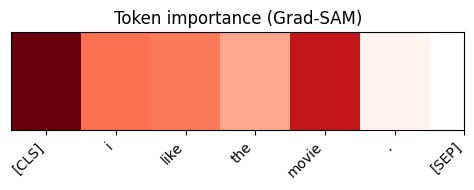

In [357]:
plot_token_importance(tokens, grad_sam_scores)

### SHAP

In [353]:
"""Implementation following https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/text.html"""

def f(x):
    # Tokenize all strings in input
    tv = torch.tensor([tokenizer(v, truncation=True,
                                 max_length=tokenizer.model_max_length,
                                 padding="max_length")["input_ids"] for v in x], device=device)

    # Fix padding stuff when input consist of several sentences
    attention_masks = torch.tensor([tokenizer(v, truncation=True, max_length=tokenizer.model_max_length,
                                              padding="max_length")["attention_mask"] for v in x], device=device)

    # Get model prediction (logits) and return the positive class
    outputs = model(input_ids=tv, attention_mask=attention_masks)[0].detach().cpu().numpy()

    return np.array(outputs[:,1]) # Positive class logits



Attention masks isn't necessary when the input is one sentence.

When the input contains several sentences of different lengst, padding tokens must be added.

Attention masks masks out padding tokens when calculating attention scores, so that only the actual input sentence is used.


In [330]:
f(sentences)

array([ 3.6635602, -3.145779 , -3.4217703,  2.665551 , -2.903021 ],
      dtype=float32)

In [331]:
explainer = shap.Explainer(f, tokenizer)
shap_values = explainer(sentences, fixed_context=1)

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 3/5 [00:55<00:32, 16.49s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 4/5 [01:24<00:21, 21.80s/it]

  0%|          | 0/56 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [02:11<00:00, 31.12s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [02:37, 31.48s/it]


In [335]:
shap_values

.values =
array([array([-0.12959369,  0.5697345 ,  2.80113624, -0.14384766,  0.32744562,
               0.17642224])                                                   ,
       array([ 0.04401791,  0.04553521, -3.53780533, -0.05805473,  0.00513335,
               0.29313202])                                                   ,
       array([ 0.30843858,  0.25726203,  0.28962771,  0.28991643, -4.94576707,
               0.31648932])                                                   ,
       array([-0.10001777,  0.30019118,  1.070114  ,  1.28322409,  0.11099617,
               0.42984835,  0.22122888, -0.22297736])                         ,
       array([ 0.59630467,  0.48589803,  0.2785715 , -0.05426274, -4.83737086,
               0.56557562])                                                   ],
      dtype=object)

.base_values =
array([ 0.06226267,  0.06226267,  0.06226267, -0.42705658,  0.06226267])

.data =
(array(['', 'I ', 'like ', 'the ', 'movie', ''], dtype=object), array(['', '

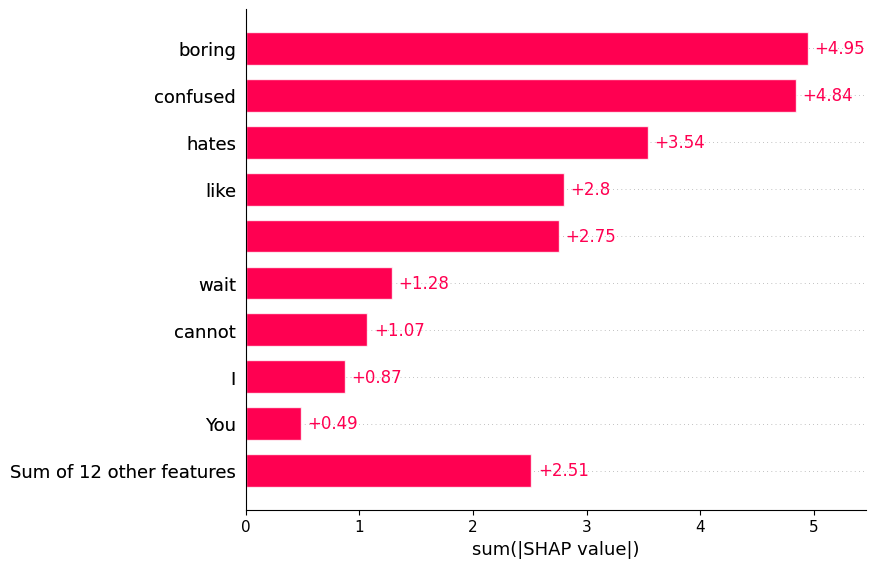

In [333]:
shap.plots.bar(shap_values.abs.sum(0))

In [ ]:
i = 3
shap.plots.initjs()
shap.plots.text(shap_values[i])

In [350]:
i = 4
shap.plots.initjs()
shap.plots.text(shap_values[i])

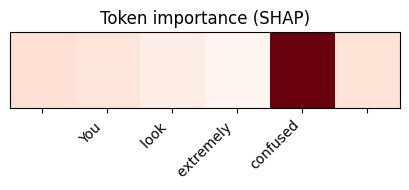

In [351]:
plot_token_importance(shap_values[i].data, np.abs(shap_values[i].values), title="Token importance (SHAP)")


 #### Comment

 Why [CLS] got high value for GRAD-SAM and not SHAP.
 This difference can be explain by  the distinct ways SHAP and GRAD-SAM measure feature importance:
In fact Grad-SAM computes importance based on thegradients of attention scores. Since BERT aggregates information from all input tokens into the [CLS] token for classification, Grad-SAM detects this concentration of information and assigns the [CLS] token the highest importance.


In another hand SHAP measures importance by evaluating the change in the model's output when a token is **masked or removed**. In BERT, the [CLS] token itself does not carry unique input information it only aggregates what other tokens provide. Therefore, removing or masking [CLS] does not change the model's prediction in the way SHAP measures importance, leading SHAP to assign it near-zero importance.

**TCAV score**

In [ ]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224').to(device)
vit.eval()


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
label2id = vit.config.label2id
class_idx = label2id.get(target_class)

positive_loader = get_vit_dataloader(p_concept_paths, processor, batch_size=batch_size)
negative_loader = get_vit_dataloader(n_concept_paths, processor, batch_size=batch_size)
target_loader = get_vit_dataloader(target_paths, processor, batch_size=batch_size)

layer = vit.vit.encoder.layer[10]

positive_activations = flatten(get_activations(vit, positive_loader, device, layer))
negative_activations = flatten(get_activations(vit, negative_loader, device, layer))

cav = train_cav(positive_activations, negative_activations)

grads = flatten(get_grads(vit, target_loader, device, layer, target_idx=class_idx))
tcav_score = tcav(cav, grads)
print(f"TCAV score: {tcav_score}")



TCAV score: 1.0


In [354]:
sentence = "I like the movie."

# Re-initialize tokenizer and model for BERT to ensure correctness
tokenizer = AutoTokenizer.from_pretrained("textattack/bert-base-uncased-SST-2")
model = AutoModelForSequenceClassification.from_pretrained("textattack/bert-base-uncased-SST-2",attn_implementation="eager").to(device)
model.eval()

input = tokenize_input(tokenizer, sentence).to(device)
output = model(**input, output_attentions=True)
logits = output.logits

# Get attention matrices for all heads and layers
attentions = output.attentions # Tuple with tensor elements of shape (batch size, num attention heads, sequence length, sequence length), one tensor per layer (i.e., encoder block)

tokens = tokenizer.convert_ids_to_tokens(input["input_ids"][0])

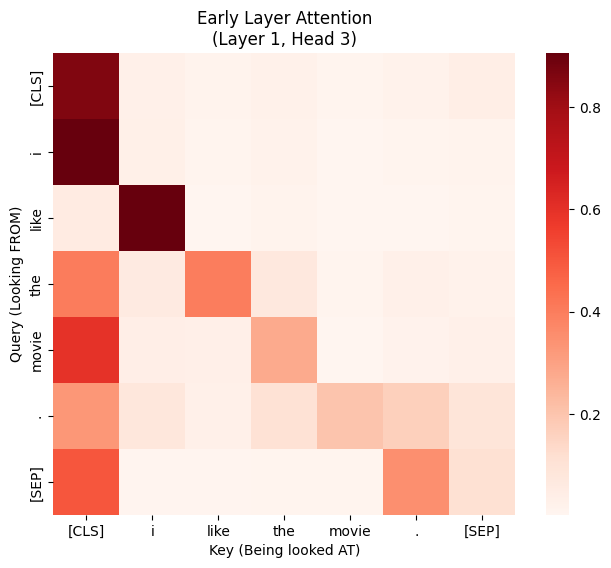

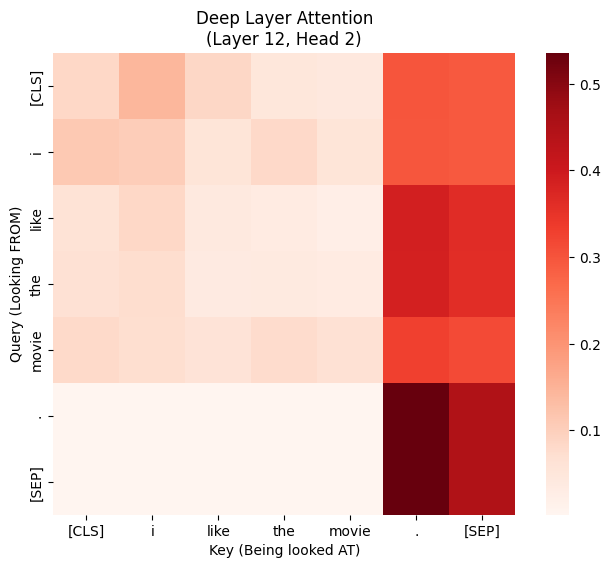

In [358]:
import seaborn as sns

def my_plot_for_head(attentions, layer_idx, head_idx, tokens, title):
    layer_attentions = attentions[layer_idx]
    head_attention = layer_attentions[0, head_idx, :, :].detach().cpu().numpy()

    # 3. Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(head_attention, xticklabels=tokens, yticklabels=tokens, cmap="Reds", square=True)
    plt.title(f"{title}\n(Layer {layer_idx + 1}, Head {head_idx + 1})")
    plt.xlabel("Key (Being looked AT)")
    plt.ylabel("Query (Looking FROM)")
    plt.show()

# Layer 1 and head 3
layer_early = 0
head_early = 2

# Layer 12 and head 2
layer_deep = 11
head_deep = 1

my_plot_for_head(attentions, layer_early, head_early, tokens, title="Early Layer Attention")
my_plot_for_head(attentions, layer_deep, head_deep, tokens, title="Deep Layer Attention")

#### comment
* Layer 1, Head 3 shows local syntactic attention.  THis plot shows a high attention between I and like, there are also between the token [CLS] AND "i".

* Layer 12, Head 2 shows a attention on vertical direction pattern that focuses on separator tokens like "." and [SEP]. Even though [CLS] is the token used for classification, also  deep layers often pay attention to [SEP] or punctuation as "attention sinks." This means this head has mostly finished processing the sentence and is now focusing on neutral tokens, ignoring words that are not important for its role.
